In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv('../.env')

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connected to database")

Connected to database


In [2]:
query = """
SELECT 
    rr.driver_id,
    rr.constructor_id,
    rr.grid_position,
    rr.finish_position,
    rr.points,
    rr.points_finish,
    rr.status,
    r.season,
    r.round,
    r.circuit_id,
    r.date,
    q.q1_time,
    q.q2_time,
    q.q3_time,
    w.air_temp,
    w.track_temp,
    w.rainfall,
    w.humidity
FROM race_results rr
JOIN races r ON rr.race_id = r.race_id
LEFT JOIN qualifying_results q ON q.race_id = rr.race_id AND q.driver_id = rr.driver_id
LEFT JOIN weather w ON w.race_id = rr.race_id
ORDER BY r.date, rr.finish_position
"""

df = pd.read_sql(query, engine)
print(df.shape)

(1398, 18)


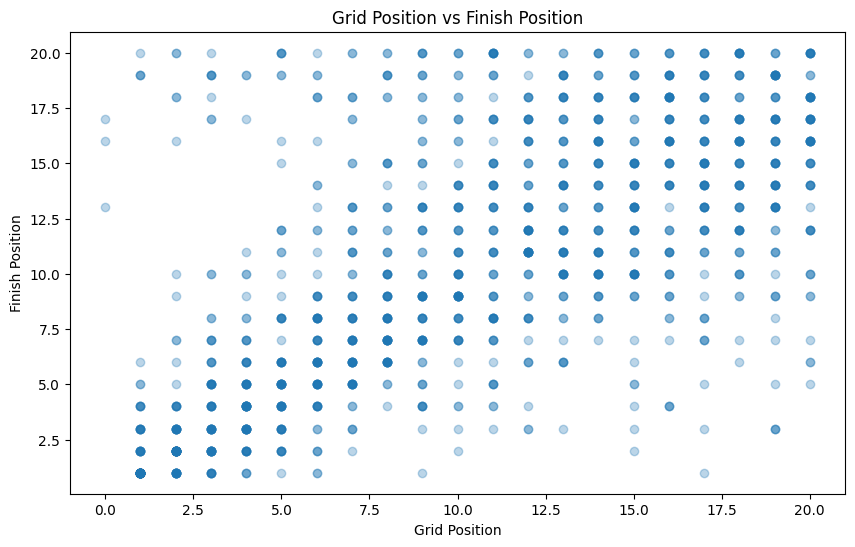

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.scatter(df['grid_position'], df['finish_position'], alpha=0.3)
plt.xlabel('Grid Position')
plt.ylabel('Finish Position')
plt.title('Grid Position vs Finish Position')
plt.show()

In [4]:
print(df['points_finish'].value_counts())
print(df['points_finish'].value_counts(normalize=True))

points_finish
True     700
False    698
Name: count, dtype: int64
points_finish
True     0.500715
False    0.499285
Name: proportion, dtype: float64


In [5]:
print(df.groupby('grid_position')['points_finish'].mean().round(2))

grid_position
0.0     0.00
1.0     0.94
2.0     0.93
3.0     0.89
4.0     0.94
5.0     0.81
6.0     0.81
7.0     0.71
8.0     0.70
9.0     0.59
10.0    0.53
11.0    0.39
12.0    0.24
13.0    0.29
14.0    0.23
15.0    0.27
16.0    0.19
17.0    0.16
18.0    0.11
19.0    0.14
20.0    0.14
Name: points_finish, dtype: float64


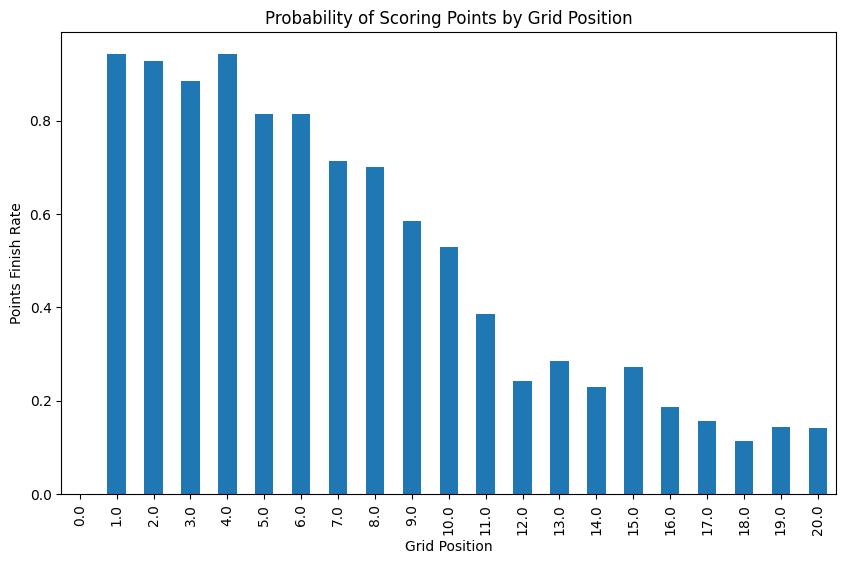

In [6]:
plt.figure(figsize=(10, 6))
df.groupby('grid_position')['points_finish'].mean().plot(kind='bar')
plt.xlabel('Grid Position')
plt.ylabel('Points Finish Rate')
plt.title('Probability of Scoring Points by Grid Position')
plt.show()

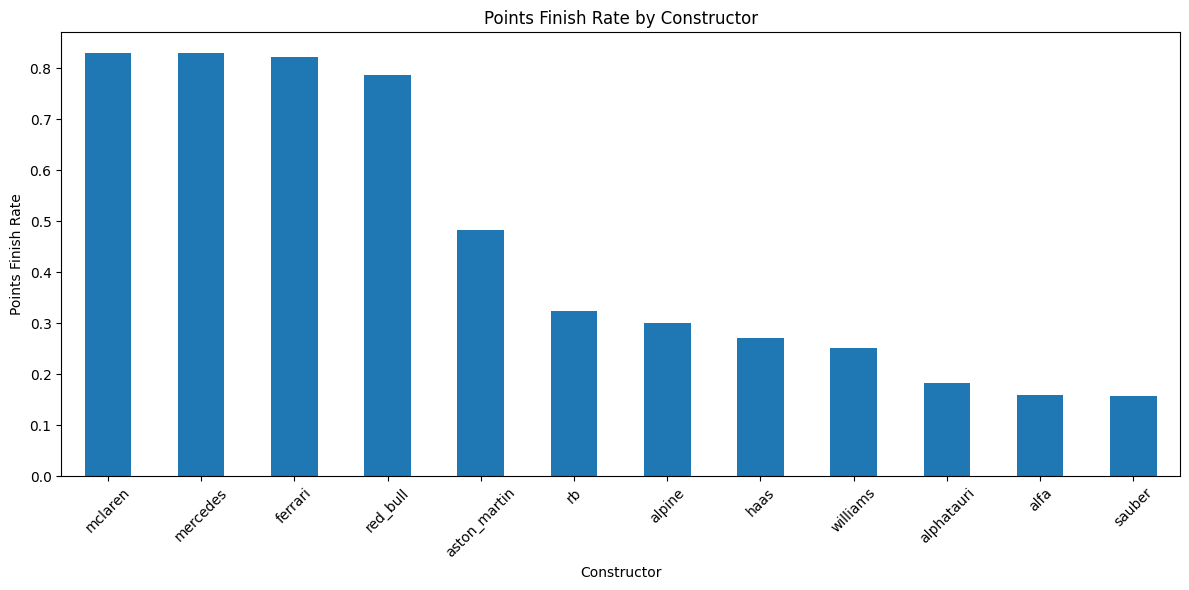

In [7]:
plt.figure(figsize=(12, 6))
df.groupby('constructor_id')['points_finish'].mean().sort_values(ascending=False).plot(kind='bar')
plt.xlabel('Constructor')
plt.ylabel('Points Finish Rate')
plt.title('Points Finish Rate by Constructor')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Calculate qualifying gap to pole position for each race
pole_times = df[df['grid_position'] == 1][['season', 'round', 'q3_time']].rename(columns={'q3_time': 'pole_time'})

df = df.merge(pole_times, on=['season', 'round'], how='left')
df['quali_gap_to_pole'] = df['q3_time'] - df['pole_time']

print(df[['driver_id', 'grid_position', 'q3_time', 'pole_time', 'quali_gap_to_pole']].head(20))

          driver_id  grid_position  q3_time  pole_time  quali_gap_to_pole
0    max_verstappen            1.0   89.708     89.708              0.000
1             perez            2.0   89.846     89.708              0.138
2            alonso            5.0   90.336     89.708              0.628
3             sainz            4.0   90.154     89.708              0.446
4          hamilton            7.0   90.384     89.708              0.676
5            stroll            8.0   90.836     89.708              1.128
6           russell            6.0   90.340     89.708              0.632
7            bottas           12.0      NaN     89.708                NaN
8             gasly           20.0      NaN     89.708                NaN
9             albon           15.0      NaN     89.708                NaN
10          tsunoda           14.0      NaN     89.708                NaN
11         sargeant           16.0      NaN     89.708                NaN
12  kevin_magnussen           17.0    

In [9]:
# Fill quali_gap_to_pole nulls with max gap in that race + 1 second penalty
df['quali_gap_to_pole'] = df.groupby(['season', 'round'])['quali_gap_to_pole'].transform(
    lambda x: x.fillna(x.max() + 1.0)
)

In [10]:
df[['driver_id', 'grid_position', 'quali_gap_to_pole']].head(20)

,driver_id,grid_position,quali_gap_to_pole
0,max_verstappen,1.0,0.000
1,perez,2.0,0.138
2,alonso,5.0,0.628
3,sainz,4.0,0.446
4,hamilton,7.0,0.676
5,stroll,8.0,1.128
6,russell,6.0,0.632
7,bottas,12.0,2.276
8,gasly,20.0,2.276
9,albon,15.0,2.276


In [18]:
# Sort by driver and date first
df = df.sort_values(['driver_id', 'date']).reset_index(drop=True)

# Rolling average finish position over last 5 races
df['driver_rolling_avg_finish'] = (
    df.groupby('driver_id')['finish_position']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

print(df[['driver_id', 'date', 'finish_position', 'driver_rolling_avg_finish']].head(30))

   driver_id        date  finish_position  driver_rolling_avg_finish
0      albon  2023-03-05             10.0                        NaN
1      albon  2023-03-19             19.0                       10.0
2      albon  2023-04-02             19.0                       14.5
3      albon  2023-04-30             12.0                       16.0
4      albon  2023-05-07             14.0                       15.0
5      albon  2023-05-28             14.0                       14.8
6      albon  2023-06-04             16.0                       15.6
7      albon  2023-06-18              7.0                       15.0
8      albon  2023-07-02             11.0                       12.6
9      albon  2023-07-09              8.0                       12.4
10     albon  2023-07-23             11.0                       11.2
11     albon  2023-07-30             14.0                       10.6
12     albon  2023-08-27              8.0                       10.2
13     albon  2023-09-03          

In [19]:
df['constructor_rolling_avg_finish'] = (
    df.groupby('constructor_id')['finish_position']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

In [24]:
# Driver's career average finish, up to (not including) this race
df['driver_career_avg'] = (
    df.groupby('driver_id')['finish_position']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Driver's average finish at this specific circuit, up to (not including) this race
df['driver_circuit_avg'] = (
    df.groupby(['driver_id', 'circuit_id'])['finish_position']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Positive = overperforms at this circuit compared to career average
df['track_delta'] = df['driver_career_avg'] - df['driver_circuit_avg']

In [25]:
df[['driver_id', 'date', 'finish_position', 'driver_career_avg', 'driver_circuit_avg', 'track_delta']].head(20)

,driver_id,date,finish_position,driver_career_avg,driver_circuit_avg,track_delta
0,albon,2023-03-05,10.0,NaN,NaN,NaN
1,albon,2023-03-19,19.0,10.000000,NaN,NaN
2,albon,2023-04-02,19.0,14.500000,NaN,NaN
3,albon,2023-04-30,12.0,16.000000,NaN,NaN
4,albon,2023-05-07,14.0,15.000000,NaN,NaN
5,albon,2023-05-28,14.0,14.800000,NaN,NaN
6,albon,2023-06-04,16.0,14.666667,NaN,NaN
7,albon,2023-06-18,7.0,14.857143,NaN,NaN
8,albon,2023-07-02,11.0,13.875000,NaN,NaN
9,albon,2023-07-09,8.0,13.555556,NaN,NaN


In [22]:
df.groupby(['driver_id', 'circuit_id']).size().value_counts()

3    292
1    190
2    166
Name: count, dtype: int64

In [27]:
df['constructor_career_avg'] = (
    df.groupby('constructor_id')['finish_position']
    .transform(lambda x: x.shift(1).expanding().mean())
)

df['driver_vs_team_delta'] = df['driver_career_avg'] - df['constructor_career_avg']

In [28]:
df_circuit_sorted = df.sort_values(['circuit_id', 'date'])
df['circuit_avg_finish'] = (
    df_circuit_sorted.groupby('circuit_id')['finish_position']
    .transform(lambda x: x.shift(1).expanding().mean())
)

In [29]:
df['driver_form_delta'] = df['driver_rolling_avg_finish'] - df['driver_career_avg']

In [30]:
df['made_q2'] = df['q2_time'].notna().astype(int)
df['made_q3'] = df['q3_time'].notna().astype(int)

In [31]:
df.columns.tolist()

['driver_id',
 'constructor_id',
 'grid_position',
 'finish_position',
 'points',
 'points_finish',
 'status',
 'season',
 'round',
 'circuit_id',
 'date',
 'q1_time',
 'q2_time',
 'q3_time',
 'air_temp',
 'track_temp',
 'rainfall',
 'humidity',
 'pole_time',
 'quali_gap_to_pole',
 'driver_rolling_avg_finish',
 'constructor_rolling_avg_finish',
 'driver_career_avg',
 'driver_circuit_avg',
 'track_delta',
 'constructor_career_avg',
 'driver_vs_team_delta',
 'circuit_avg_finish',
 'driver_form_delta',
 'made_q2',
 'made_q3']

In [32]:
df.columns.tolist()

['driver_id',
 'constructor_id',
 'grid_position',
 'finish_position',
 'points',
 'points_finish',
 'status',
 'season',
 'round',
 'circuit_id',
 'date',
 'q1_time',
 'q2_time',
 'q3_time',
 'air_temp',
 'track_temp',
 'rainfall',
 'humidity',
 'pole_time',
 'quali_gap_to_pole',
 'driver_rolling_avg_finish',
 'constructor_rolling_avg_finish',
 'driver_career_avg',
 'driver_circuit_avg',
 'track_delta',
 'constructor_career_avg',
 'driver_vs_team_delta',
 'circuit_avg_finish',
 'driver_form_delta',
 'made_q2',
 'made_q3']

In [33]:
df[['grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_form_delta', 'driver_career_avg', 'driver_circuit_avg',
    'track_delta', 'constructor_career_avg', 'driver_vs_team_delta',
    'air_temp', 'track_temp', 'rainfall', 'humidity']].isnull().sum()

grid_position                       1
quali_gap_to_pole                   0
made_q2                             0
made_q3                             0
driver_rolling_avg_finish          28
constructor_rolling_avg_finish     12
driver_form_delta                  28
driver_career_avg                  28
driver_circuit_avg                649
track_delta                       649
constructor_career_avg             12
driver_vs_team_delta               31
air_temp                            0
track_temp                          0
rainfall                            0
humidity                            0
dtype: int64

In [34]:
df.groupby(['circuit_id', 'date']).size()

circuit_id  date      
Austin      2023-10-22    20
            2024-10-20    20
            2025-10-19    20
Baku        2023-04-30    20
            2024-09-15    20
                          ..
Yas Island  2024-12-08    20
            2025-12-07    20
Zandvoort   2023-08-27    20
            2024-08-25    20
            2025-08-31    20
Length: 70, dtype: int64

In [35]:
df.groupby('circuit_id')['date'].nunique()

circuit_id
Austin               3
Baku                 3
Barcelona            3
Budapest             3
Imola                2
Jeddah               3
Las Vegas            3
Lusail               3
Marina Bay           3
Melbourne            3
Mexico City          3
Miami                2
Miami Gardens        1
Monaco               3
Montréal             3
Monza                3
Sakhir               3
Shanghai             2
Silverstone          3
Spa-Francorchamps    3
Spielberg            3
Suzuka               3
São Paulo            3
Yas Island           3
Zandvoort            3
Name: date, dtype: int64

In [36]:
df[['grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_form_delta', 'driver_career_avg', 'driver_circuit_avg',
    'track_delta', 'constructor_career_avg', 'driver_vs_team_delta',
    'air_temp', 'track_temp', 'rainfall', 'humidity']].isnull().sum()

grid_position                       1
quali_gap_to_pole                   0
made_q2                             0
made_q3                             0
driver_rolling_avg_finish          28
constructor_rolling_avg_finish     12
driver_form_delta                  28
driver_career_avg                  28
driver_circuit_avg                649
track_delta                       649
constructor_career_avg             12
driver_vs_team_delta               31
air_temp                            0
track_temp                          0
rainfall                            0
humidity                            0
dtype: int64

In [37]:
df['has_circuit_history'] = df['driver_circuit_avg'].notna().astype(int)

In [38]:
# Boolean flags for missing history
df['has_circuit_history'] = df['driver_circuit_avg'].notna().astype(int)

# Fill grid_position
df['grid_position'] = df['grid_position'].fillna(20)

# Fill driver/constructor career and rolling averages with overall mean
overall_mean_finish = df['finish_position'].mean()

df['driver_rolling_avg_finish'] = df['driver_rolling_avg_finish'].fillna(overall_mean_finish)
df['driver_career_avg'] = df['driver_career_avg'].fillna(overall_mean_finish)
df['constructor_rolling_avg_finish'] = df['constructor_rolling_avg_finish'].fillna(overall_mean_finish)
df['constructor_career_avg'] = df['constructor_career_avg'].fillna(overall_mean_finish)

# Fill driver_circuit_avg with their own career average (best guess without circuit history)
df['driver_circuit_avg'] = df['driver_circuit_avg'].fillna(df['driver_career_avg'])

# Fill delta features with 0 (neutral - no difference from norm)
df['track_delta'] = df['track_delta'].fillna(0)
df['driver_form_delta'] = df['driver_form_delta'].fillna(0)
df['driver_vs_team_delta'] = df['driver_vs_team_delta'].fillna(0)

print("NaNs remaining:")
print(df.isnull().sum().sum())

NaNs remaining:
1119


In [39]:
df.isnull().sum()[df.isnull().sum() > 0]

finish_position         1
q1_time                17
q2_time               363
q3_time               713
circuit_avg_finish     25
dtype: int64

In [40]:
feature_columns = [
    'grid_position', 'quali_gap_to_pole', 'made_q2', 'made_q3',
    'driver_rolling_avg_finish', 'constructor_rolling_avg_finish',
    'driver_career_avg', 'driver_circuit_avg', 'track_delta',
    'constructor_career_avg', 'driver_vs_team_delta', 'driver_form_delta',
    'has_circuit_history',
    'air_temp', 'track_temp', 'rainfall', 'humidity',
    'constructor_id', 'circuit_id'
]

model_df = df[feature_columns + ['points_finish', 'season', 'round', 'date']].copy()

print(model_df.isnull().sum().sum())
print(model_df.shape)

0
(1398, 23)
